## **Important Information:**
1.   The pretraied model is loaded in the variable `model`.
2.   All clean images and labels are loaded as tensors `X` and `y_true` respectively such that `y_true[i]` is the actual label of `X[i]`.
3.   To predict all labels call `model(X)`.
4.   Please properly follow the instructions corresponding to each of the following cells.

## **Specify the data path**
In the following cell provide appropriate path to the "p2_data.zip" file.

In [1]:
# EDIT THE PATH IF NEEDED
zip_path = "p2_data.zip" # path to the "p2_data.zip" file.

## **Load data file**
**Do not edit the following cell.**

In [2]:
# DO NOT EDIT THIS CELL

import zipfile

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall()

with open("./p2_data/readme.txt", "r") as f:
    print(f.read())

readme.txt:
-----------

Clean images are available in the folder "/p2_data/clean_images/"

There are 1000 clean images (10 classes * 100 images per class)

Image file path format is "/p2_data/clean_images/<class_name>_<index>.png"
     <class_name>: Name of the true class of the image
                   Can be among {airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck}
     <index>     : Index of the image ranging from 0 to 99

There is an empty folder "/p2_data/adv_images/". You can use it for saving your adversarial images.

The pretrained model is "/p2_data/cnn_model.pt"


## **Prepare the model and data**
1. **Do not edit the following cell.**
2. The variable `class_names` contains name of the output labels.
3. The variables `mean` and `std` are used to normalize the input images using mean and standard deviation.



Total images: 1000  |  Correctly Classified: 1000
Showing some sample images ...


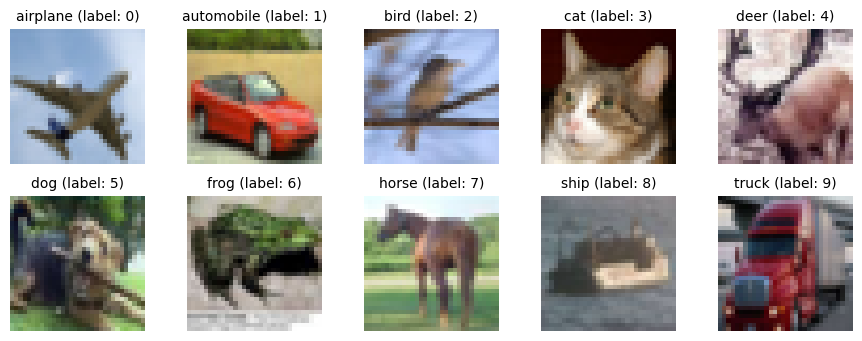

In [3]:
# DO NOT EDIT THIS CELL

import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

mean = (0.4914, 0.4822, 0.4465) # image mean
std  = (0.2470, 0.2435, 0.2616) # image standard deviation
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
img_per_class = 100

# prepare input images
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)]) # specify transformations: covert to tensor and normalize
paths = [f"./p2_data/clean_images/{name}_{i}.png" for name in class_names for i in range(img_per_class)]
labels = [class_names.index(name) for name in class_names for _ in range(img_per_class)]
X = torch.stack([transform(Image.open(p).convert("RGB")) for p in paths], dim = 0).to(device) # convert to tensor and normalize
y_true = torch.tensor(labels).to(device) # convert to tensor

# load cnn model
model = torch.jit.load("./p2_data/cnn_model.pt", map_location = device)

# sanity check
y_pred = model(X)
matches = (y_true == y_pred)
print(f"Total images: {len(y_true)}  |  Correctly Classified: {sum(matches).item()}")

# show some images
print("Showing some sample images ...")
mean_t = torch.tensor(mean).view(3, 1, 1)
std_t  = torch.tensor(std).view(3, 1, 1)
fig, axes = plt.subplots(2, 5, figsize=(9, 3.5))
for i, idx in enumerate([59, 119, 283, 360, 427, 527, 682, 783, 806, 991]):
    img = (X[idx].cpu() * std_t + mean_t).clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()
    ax = axes[i // 5, i % 5]
    ax.imshow(img)
    ax.set_title(f"{class_names[idx // img_per_class]} (label: {labels[idx]})", fontsize = 10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## **Adversarial Attack**
Implement your attack in the following cell.
1. You can only call `model()` as a **black box oracle** and use the output.
2. Your method **must not** see the actual parameters or architecture.
3. Your method **must not** see the intermediate layer outputs including class probabilities.

In [4]:
# IMPLEMENT YOUR ATTACK HERE
!pip install foolbox
import foolbox as fb
import torch.nn as nn
from tqdm import tqdm
import os
import numpy as np
from PIL import Image

class ModelWrapper(nn.Module):
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.base_model = base_model
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1).to(device))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1).to(device))
        
    def forward(self, x):
        x_norm = (x - self.mean) / self.std
        labels = self.base_model(x_norm)
        logits = torch.zeros(x.size(0), 10, device=x.device)
        logits.scatter_(1, labels.view(-1, 1), 1.0)
        return logits

model_wrapped = ModelWrapper(model, mean, std).to(device)
model_wrapped.eval()

fmodel = fb.PyTorchModel(model_wrapped, bounds=(0, 1), device=device)
attack = fb.attacks.HopSkipJumpAttack(steps=15)

print("Starting attack...")
batch_size = 50
all_advs = []

for i in tqdm(range(0, len(X), batch_size)):
    x_batch = X[i:i+batch_size]
    y_batch = y_true[i:i+batch_size]
    
    _, advs, success = attack(fmodel, x_batch, criterion=fb.criteria.Misclassification(y_batch), epsilons=None)
    all_advs.append(advs)

# Combine all adversarial images
X_adv = torch.cat(all_advs, dim=0)



## **Save Adversarial Images**
1. You must save the one adversarial image corresponding to each clean image as `.png`.
2. You must follow the naming convention. For example, the adversarial image corresponding to `cat_5.png` must be saved as `cat_5_adv.png`, so that during evaluation they can be compared.
3. Save all the adversarial images in the same folder and name it `adv_images`.
4. Make sure the images are properly denormalized using the same `mean` and `std`. This is essential since it can affect the quality of your adversarial images if not done properly.

In [5]:
# SAVE ADVERSARIAL IMAGES
adv_images_dir = "./p2_data/adv_images"
os.makedirs(adv_images_dir, exist_ok=True)

for i in range(len(X_adv)):
    adv_img = X_adv[i].cpu().detach().permute(1, 2, 0).numpy()
    adv_img = (adv_img * 255).astype(np.uint8)
    img = Image.fromarray(adv_img)
    
    orig_path = paths[i]
    basename = os.path.basename(orig_path).replace(".png", "_adv.png")
    img.save(os.path.join(adv_images_dir, basename))

print(f"Saved {len(X_adv)} adversarial images to {adv_images_dir}")



### **Submission:** Complete this notebook and submit along with adversarial images in adv_images folder.